In [1]:
%%bash

pip install rasterio
pip install pillow
pip install cmweather
wget -nc -q https://nimbus.niu.edu/courses/EAE483/BREF_090508_1300.png
wget -nc -q https://nimbus.niu.edu/courses/EAE483/000000274089.tif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 1.9 MB/s eta 0:00:00


# Chapter 9.1 - Digital Image Processing

[Digital image processing](https://en.wikipedia.org/wiki/Digital_image_processing) describes a set of algorithms that can be used to manipulate digital images. Many of these algorithms are foundational for deep learning and other modern machine learning approaches. In this chapter, we will introduce how images are represented in computer systems, visualization and interpretation of digital images, common algorithms used to modify these images, and machine learning models that work with images.

### Chapter 9.1.1 - What is a digital image?

In a previous chapter, we introduced the [raster data model](https://ahaberlie.github.io/python_programming_geosciences/raster-data-analysis/). We learned that, in Python, rasters are represented as numeric arrays of two or more dimensions. Each number in the raster represents the value within a *grid cell*. Each grid cell represents some region from which a measurement was taken. For example, when taking a picture with a camera, each pixel is representing the intensity detected by the camera's sensor in certain spectral bands.

Humans [perceive colors](https://en.wikipedia.org/wiki/Color_vision) using specialized cells on our retinas called [cones](https://en.wikipedia.org/wiki/Color_vision#Cone_cells_in_the_human_eye). Each cone is more sensitive to relative visible frequencies--namely, the S cone (400-500 nm), M cone (450-630 nm), and L cone (500-700 nm). While these are commonly connected to the wavelength at which they are most sensitive--blue (420 nm), green (534 nm), and red (564 nm), respectively--the actual sensitivity is better represented by a spectrum centered on those colors. For example, M and L cones are sensitive to green and red.

![cones and rods](https://upload.wikimedia.org/wikipedia/commons/thumb/f/f1/1416_Color_Sensitivity.svg/1920px-1416_Color_Sensitivity.svg.png)

### Chapter 9.1.2 - RGB Color Model

That said, the so-called ["RGB" color model](https://en.wikipedia.org/wiki/RGB_color_model) is based on a simplification of the human visual system. Information from sensors (e.g., cameras, satellite platforms, etc.) are processed based on the intensity of light at the red, green, and blue wavelengths. In the raster data model, this requires the array to be three dimensional--two dimensions for space (e.g., x and y), and one dimension for the individual intensities of red, green, or blue light captured by the sensor. The third dimension of the RGB color model is often called a "channel". If a pixel value has a non-zero intensity for the red channel and a zero intensity for the green and blue channels, the pixel will be assigned the color red. A healthy combination of green and red channel intensities, with no blue intensity, will produce a yellow, etc.

![color mixing](https://upload.wikimedia.org/wikipedia/commons/9/91/Venn_diagram_rgb.svg)

**Hexadecimal and Decimal Encoding**

In an 8-bit RGB image, each pixel stores three integers: one for red, one for green, and one for blue. Each channel ranges from 0 to 255, so one pixel can be written as (R, G, B), such as (0, 128, 255). The same color can also be written in hexadecimal form as #RRGGBB, where each pair of hex digits encodes one channel. For example, #FFFFFF corresponds to (255, 255, 255) and #000000 corresponds to (0, 0, 0).

You may also see colors encoded as a hexadecimal value. A hexadecimal value (or "hex code"; e.g., `#FF0000`) is often used to encode specific colors using 8 bits (1 byte) to store each color intensity--specifically:

 Channel | Digits | Size | HEX example for 'black' | Equivalent Raw Binary for 'black' (disk storage) |
|-------------|---------|-------|--------|---------|
| Red   |  1-2 | 8 bits | 00| 00000000
| Green |  3-4 | 8 bits | 00| 00000000|
| Blue  |  5-6 | 8 bits | 00| 00000000|

In other words, 1 pixel of raw RGB information stored on a disk (uncompressed) will take up 3 bytes (24 bits) of space. Black, for example, can be represented through a hexadecimal as `000000`, and in binary as:

`00000000 00000000 00000000`

Each two-digit sequence can encode 256 different intensities for each color, and the 3 sequences together encode more than 16 million unique colors. A nice website for exploring colormaps and generating hex codes is ColorBrewer: https://colorbrewer2.org/.

The maximum hex value (`FF`) for any color is equivalent to an integer of `255`. So, using the hex code of `#FFFFFF` for a color is equivalent to an RGB array of `(255, 255, 255)`.

Hexadecimal values use a `base-16` numbering system. We typically use a `base-10` system, where all possible numbers are just combinations of the digits 0-9. Conversions from `base-16 (hexadecimal)` to `base-10 (decimal)` for one digit is as follows:

| Hexadecimal | Decimal |
|-------------|---------|
| 0           | 0       |
| 1           | 1       |
| 2           | 2       |
| 3           | 3       |
| 4           | 4       |
| 5           | 5       |
| 6           | 6       |
| 7           | 7       |
| 8           | 8       |
| 9           | 9       |
| A           | 10      |
| B           | 11      |
| C           | 12      |
| D           | 13      |
| E           | 14      |
| F           | 15      |

To get the number `16`, we just repeat the cycle by adding another digit. We set the first digit to 1, and the second digit to 0. This results in an unintuitive solution!

`10`

This unintuitively is equivalent to `16` in `base-10`.

For two digits, the hex-to-base-10 conversion, after converting each digit to a value between 0 and 15, is as follows:

```
base10 = (first_digit * 16**1) + (second_digit * 16**0)
```

The exponents increment for every additional digit. For example, if you have three digits `1F1`:

```
base16_to_10 = (1 * 16**2) + (15 * 16**1) + (1 * 16**0)
```

This is equivalent to 497 in decimal.


This seems odd until you realize that going from 9 to 10 is just repeating the `base-10` cycle when you run out of digits:

256 in `base-10` can be described using the same equation above:

```
base10_expansion = (2 * 10**2) + (5 * 10**1) + (6 * 10**0)
```

This might make `binary` or `base-2` make more sense to you. This is how computers store data types like integers. If we assume that each digit is going to be multiplied by `2$^{n}`, where `n` is the number of digits, that makes storing values very convenient in a system that was designed to send "on" and "off" signals to transfer and process data.

So, `10` in binary is what in decimal? 2!

```
base2_to_10 = (1 * 2**1) + (0 * 2**0)
```

So, the digits `10` can be a value of:

1. `10` in `base-10`
2. `16` in `base-16`
3. `2` in `base-2`

Other common `base` types include:

2. [`base-64` for encoding text on webpages and emails](https://en.wikipedia.org/wiki/Base64)
>> less intuitive, but maps the numbers 0 - 63 to various letters and symbols. E.g., `0` is `A`, `62` is '+', etc.
3. [`base-8`, most commonly seen in `linux` permissions](https://en.wikipedia.org/wiki/Octal)
>> When setting permissions with commands like `chmod`, you specify three digits in the order owner, group, and others. For each digit, permissions are calculated as the sum of the values read (`4`), write (`2`), and execute (`1`). The owner is the user who owns the file or directory, the group refers to the file's assigned group, and others includes everyone who is neither the owner nor a member of that assigned group. `755` means: the owner gets read, write, and execute (4 + 2 + 1 = 7), the group gets read and execute (4 + 1 = 5), and others get read and execute (4 + 1 = 5).


**Image Compression**

Before, we discussed that we can store a pixel value representing a color on disk in 24-bit binary form that takes up 3 bytes of data:

`00000000 00000000 00000000`

If we instead store the image in [grayscale](https://en.wikipedia.org/wiki/Grayscale), we could reduce the size of each pixel to 8-bits (1 byte):

`00000000`

Grayscale images are commonly used in geoscience applications. For example, the radar images we examined in previous chapters were grayscale, 8-bit images that only used a fraction of the 8-bit `int` space (e.g., 0 - ~80 dBZ). If we used color quantization, we could potentially encode ranges of 5 dBZ into 16 values (0 - 16) and pack them into a 4 bit image. However, Python (specifically, numpy) only provides an 8-bit `int` type.

**Try it yourself**: We can examine the values of a grayscale radar image below. What are the differences between the grayscale image and the RGB image?















(1837, 3661)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


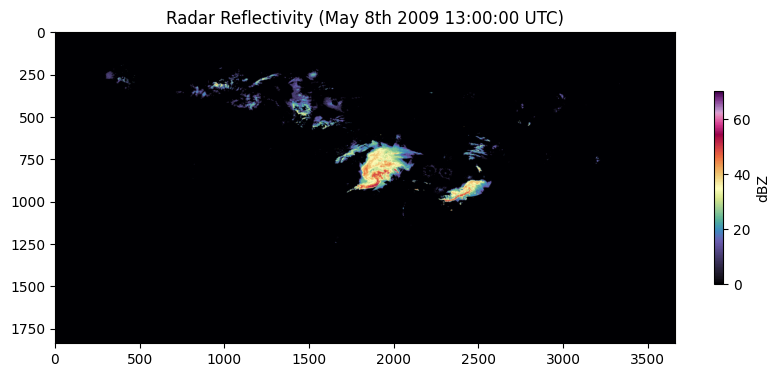

In [3]:
import matplotlib.pyplot as plt

import cmweather
import numpy as np
from PIL import Image

plt.rcParams['figure.figsize'] = 10, 10

img = Image.open("BREF_090508_1300.png")
img = np.array(img)

print(img.shape)

plt.imshow(np.array(img) * 5, cmap='ChaseSpectral')
plt.title("Radar Reflectivity (May 8th 2009 13:00:00 UTC)")
cbar = plt.colorbar(shrink=0.25)
cbar.set_label("dBZ")

print(img)

Interestingly, the grayscale radar image is *smaller* in size on disk (67.29 KB) compared to the RGB geotiff (198 KB), despite having the dimensions of (1837, 3661) vs. (128, 128, 3).

In [4]:
from pathlib import Path

path = Path("BREF_090508_1300.png")
size_bytes = path.stat().st_size

print(f"Gray Bytes: {size_bytes}")
print(f"Gray KB: {size_bytes / 1024:.2f}")
print(f"Gray MB: {size_bytes / (1024**2):.4f}")

from pathlib import Path

path = Path("000000274089.tif")
size_bytes = path.stat().st_size

print(f"RGB Bytes: {size_bytes}")
print(f"RGB KB: {size_bytes / 1024:.2f}")
print(f"RGB MB: {size_bytes / (1024**2):.4f}")

Gray Bytes: 68900
Gray KB: 67.29
Gray MB: 0.0657
RGB Bytes: 203399
RGB KB: 198.63
RGB MB: 0.1940


While the 8-bit vs. 24-bit tells part of the story, the other part is in how the [`png` (Portable Network Graphics)](https://en.wikipedia.org/wiki/PNG) compression works.

There are two types of compression algorithms:

1. `lossless`: the original pixel values can be recovered after compression
2. `lossy`: the original pixel values are only approximately recovered after compression (e.g., [JPEG](https://en.wikipedia.org/wiki/JPEG))

The distinction is very important. `JPEG` might work for storing family photos, but might be too destructive for geoscience data. For example, the JPEG compression is a multi-step process that tries to eliminate unneeded data in an image. While the compression results are impressive, legitimate data can be lost forever.

In contrast, `PNG` works by identifying `runs` in images and transforming rows of values into sequences of:

`(how many times does the value repeat, repeated value)`


For example, consider one row of a grayscale image:

`0, 0, 0, 0, 0, 0, 255, 255, 255, 255, 255, 0, 0, 0`

could be stored as a representation that resembles this:

`6, 0, 5, 255, 3, 0`

The `PNG` decoder would know that all odd values are the repeat count, and the even numbers are the repeated value.

**Try it yourself**: Try to write a `png` encoder that can convert one 8-bit line into a compressed representation.

In [5]:
raw_values = np.array([0, 0, 0, 0, 0, 0, 255, 255, 255, 255, 255, 0, 0, 0])

**Try it yourself**: Using what you know about `hexadecimal` and `decimal` values, modify the RGB array values (i.e., `decimal`) below to get the following hexadecimal values. What colors do they represent?

1. `#FFFFFF`
2. `#FF0000`
3. `#00FF00`
4. `#0000FF`
5. `#000000`

**Try it yourself**: Based on the color blending figure above, approximately create the following colors. What `hexadecimal` and RGB `decimal` codes most closely match to those colors?

1. `Orange`
2. `Yellow`
3. `Purple`
4. `Grey`

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def show_pixel(r=128, g=128, b=128):
    pixel = np.array([[[r, g, b]]], dtype=np.uint8)
    hex_color = f"#{r:02X}{g:02X}{b:02X}"

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(pixel, interpolation='nearest')
    ax.set_title(f"RGB = ({r}, {g}, {b})\n{hex_color}", fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

r_slider = widgets.IntSlider(value=128, min=0, max=255, step=1, description='R')
g_slider = widgets.IntSlider(value=128, min=0, max=255, step=1, description='G')
b_slider = widgets.IntSlider(value=128, min=0, max=255, step=1, description='B')

widgets.interact(show_pixel, r=r_slider, g=g_slider, b=b_slider);

interactive(children=(IntSlider(value=128, description='R', max=255), IntSlider(value=128, description='G', ma…

**Single-pixel HSV Image**

The [`HSV` (Hue, Saturation, Value)](https://en.wikipedia.org/wiki/HSL_and_HSV) color model is similar, but instead encodes images using:

1. Hue — the basic color type, such as red, orange, yellow, green, blue, or violet.
2. Saturation — how vivid or pure the color is, ranging from gray and dull to rich and intense.
3. Value — the brightness of the color, ranging from dark to bright.

![hsv](https://upload.wikimedia.org/wikipedia/commons/3/33/HSV_color_solid_cylinder_saturation_gray.png)

You can modify the `HSV` values below to get a particular color. Notice that the `colorsys` package converts `HSV` to `RGB`. Much like the `decimal` system, the `RGB` system serves as the universal color system for matplotlib.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import colorsys

def show_hsv_patch(h=180, s=0.5, v=0.5):
    r, g, b = colorsys.hsv_to_rgb(h / 360.0, s, v)
    patch = np.ones((50, 50, 3), dtype=float)
    patch[..., 0] = r
    patch[..., 1] = g
    patch[..., 2] = b

    r255 = int(round(r * 255))
    g255 = int(round(g * 255))
    b255 = int(round(b * 255))

    hex_color = f"#{r255:02X}{g255:02X}{b255:02X}"

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(patch)
    ax.set_title(f"HSV=({h:.0f}, {s:.2f}, {v:.2f})\nRGB=({r255}, {g255}, {b255})\n{hex_color}")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

widgets.interact(
    show_hsv_patch,
    h=widgets.IntSlider(value=180, min=0, max=360, step=1, description='H'),
    s=widgets.FloatSlider(value=0.5, min=0, max=1, step=0.01, description='S'),
    v=widgets.FloatSlider(value=0.5, min=0, max=1, step=0.01, description='V')
);

interactive(children=(IntSlider(value=180, description='H', max=360), FloatSlider(value=0.5, description='S', …

**Try it yourself**

Modify the following 4 pixel array (2x2) named `color_arr` to display the colors `red`, `green`, `blue`, and `black`

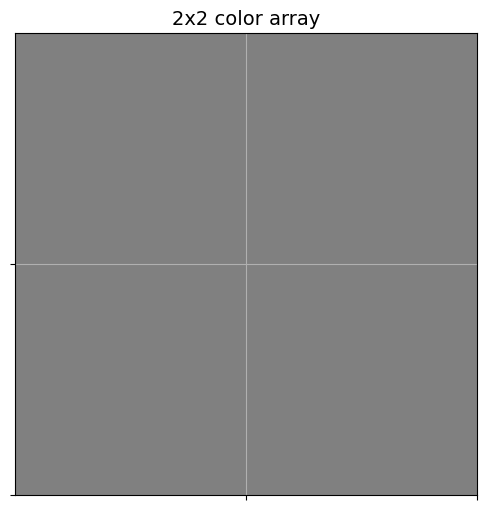

In [8]:
color_arr = [[(128, 128, 128), (128, 128, 128)],
             [(128, 128, 128), (128, 128, 128)]]


pixels = np.array(color_arr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(pixels, interpolation='nearest')
ax.set_title("2x2 color array", fontsize=14)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels([])
ax.set_xticklabels([])
plt.grid()

**Real world RGB Example**

The United States Geological Survey (USGS) has a repository of NAIP ([National Agriculture Imagery Program](https://naip-usdaonline.hub.arcgis.com/)) imagery. These images are RGB composites collected by sensors on aircraft, and offer a resoluton of 0.6 m (or better) per grid. This dataset is primarily to monitor crops during the growing season. However, there are many other applications of these data, including building and event detection.

We can read in these data using `rasterio`. When you display the data contained within the array `arr`, you can see it is just a 3D array of values ranging from 0 - 255. The first dimension is the `channel` (RGB), the 2nd dimension is `y` (i.e., northing), and the 3rd dimension is `x` (i.e., easting).

In [9]:
import rasterio

tif_path = "000000274089.tif"

with rasterio.open(tif_path) as src:
    arr = src.read()
    profile = src.profile

print("Array shape:", arr.shape)
print("Data type:", arr.dtype)
print("Profile:")
print(profile)

print(arr)

Array shape: (3, 256, 256)
Data type: uint8
Profile:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 256, 'height': 256, 'count': 3, 'crs': CRS.from_wkt('PROJCS["NAD83 / UTM zone 16N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26916"]]'), 'transform': Affine(0.5999999999999996, 0.0, 633510.0,
       0.0, -0.6000000000999995, 3665995.199991812), 'blockxsize': 128, 'blockysize': 128, 'tiled': True, 'compress': 'lzw', 'interleave': 'pixel'}
[[[170 138 105 ... 157 159 161]

We can plot these data using matplotlib, but we first need to `transpose` the data into a different orientation of dimensions. `matplotlib` requires RGB data to be organized with `channels` as the last dimension. It can be difficult to figure out how to shuffle the data dimensions around. Luckily, `numpy` has a built-in transpose function:

```
rgb = np.transpose(arr, (1, 2, 0)
```

Where the first argument is the original array, the 2nd argument is the new order of dimensions. In other words, (1, 2, 0) when passed into this method will do the following conversion that sets it up nicely for matplotlib.

| Original | `transpose` |
|----------|------------|
| 0        | 1          |
| 1        | 2          |
| 2        | 0          |

**Try it yourself**: Use the widgets below to modify the R, G, and/or B channels with a fractional adjustment, where `2` is 200% and `0` is 0%. Are there any details about the image that are more / less obvious if a channel is dampened (scale < 1) or amplified (scale > 1)?

In [10]:
rgb = np.transpose(arr[:3], (1, 2, 0))

def adjust_rgb(r_scale=1.0, g_scale=1.0, b_scale=1.0):
    out = rgb.astype(np.float32).copy()

    out[:,:,0] *= r_scale
    out[:,:, 1] *= g_scale
    out[:,:, 2] *= b_scale

    out = np.clip(out, 0, 255).astype(np.uint8)

    plt.figure(figsize=(5, 5))
    plt.imshow(out)
    plt.title(f"R × {r_scale:.2f}, G × {g_scale:.2f}, B × {b_scale:.2f}")
    plt.axis("off")
    plt.show()

widgets.interact(
    adjust_rgb,
    r_scale=widgets.FloatSlider(value=1.0, min=0.0, max=2.0, step=0.01, description='R'),
    g_scale=widgets.FloatSlider(value=1.0, min=0.0, max=2.0, step=0.01, description='G'),
    b_scale=widgets.FloatSlider(value=1.0, min=0.0, max=2.0, step=0.01, description='B'),
);

interactive(children=(FloatSlider(value=1.0, description='R', max=2.0, step=0.01), FloatSlider(value=1.0, desc…